In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
# import statsmodels.formula.api as smf
# rom statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.graphics.gofplots import ProbPlot

Problem 1: [50 points]
In this problem, we are going to use a simulated example to illustrate the behavior of testing
and training errors as the number of predictor increases.
(a) [5 points] Generate a data set with p = 20 (independent) covariates, n = 1, 000 observa-
tions and an associated quantitative response vector generated according to the model
Y = Xβ + ε
where β is the following vector:
β = (1, 0.5, 0, −0.5, −1, 1, 0.5, 2, 0, 0, 0.1, 0.2, 2, 0, 0, 0, −2, 1, 0, 0)
The covariates and the ε can be generated using standard normal random variables. (This
is similar to what you did in Coding Assignment # 1).

In [59]:
np.random.seed(598)
n, p = 1000, 20
beta = np.array([1, 0.5, 0, -0.5, -1, 1, 0.5, 2, 0, 0, 0.1, 0.2, 2, 0, 0, 0, -2, 1, 0, 0])
X = np.random.normal(0, 1, (n,p))
# matrix of all the random distributions -- n,p shape
# print(X)
print(X.shape)
epsilon = np.random.normal(0,1,n)

Y = X @ beta + epsilon
# print(Y)
# matrix multiplication to get the full output (single row)





(1000, 20)


(b) [5 points] Randomly split your data set into a training set containing 200 observations
and a test set containing 800 observations.

In [60]:
x_train = X[:200,:]
x_test = X[200:,:]

y_train = Y[:200]
y_test = Y[200:]
# because they're random, just choosing the first 200 indexes should be "random" and replicable. 

(c) [10 points] Perform best subset selection on the training set, and plot the training set
MSE associated with the best model of each size

In [61]:
from itertools import combinations
x_train = X[:200,:]
x_test = X[200:,:]

y_train = Y[:200]
y_test = Y[200:]

#I accidentally did c and d backwards, so sorry for the ugly code

mses = []
#best mse search for each combination size
xtrain_c = sm.add_constant(x_train) #intercept
# xtest_c = sm.add_constant(x_test) #intercept
for k in range(0, p+1):
    best_mse = float('inf')
    for combo in combinations(range(p),k):
        #creates a tuple with indices for each combination
        xtrain_sub = xtrain_c[:, (0,) + combo]
        # xtest_sub = xtest_c[:,(0,) +combo]
        # small time optimization
        # didn't know numpy could do column selection until my friend told me (: 

        model = sm.OLS(y_train, xtrain_sub).fit()
        y_pred = model.predict(xtrain_sub)
        mse = np.mean((y_train - y_pred) ** 2)
        if mse < best_mse:
            best_mse = mse
    mses.append(best_mse)
 #this probably works but it takes way too much time




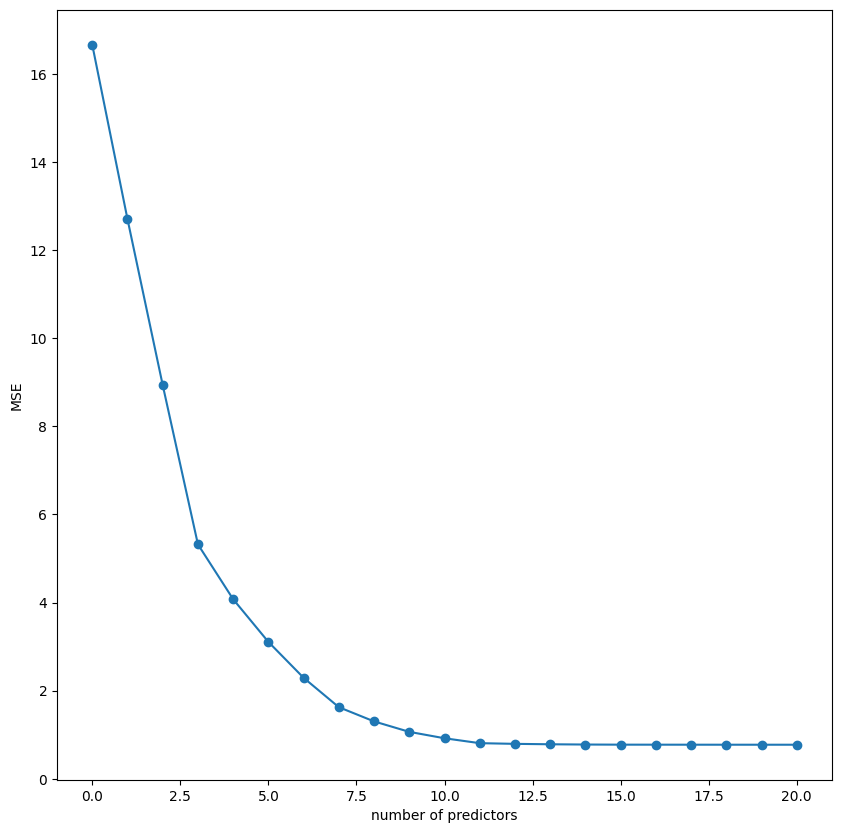

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(range(0, p+1), mses, marker='o')
plt.xlabel("number of predictors")
plt.ylabel("MSE")
plt.show()

d) 10 points] Plot the test set MSE associated with the best model of each size.

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13)
[ 0.1550662   0.1550662   0.81809371  0.06972312  0.19702359 -0.52187777
 -1.10524546  1.08468161  0.63841185  1.99000003  0.42189367  0.07171872
  0.13901528  0.04661842  1.95532044]
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 17)
[ 0.00266629  0.00266629  1.25825783  0.47788238  0.0292381  -0.5090412
 -1.25102476  1.28125729  0.62364424  1.93053992  0.09568346  0.00782407
  0.34518712  0.49360044 -2.06810717]
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 17)
[ 0.01859989  0.01859989  1.03365469  0.37979895  0.07175236 -0.50563242
 -1.23112748  0.99697351  0.44853758  2.08637844  0.07055398  0.08594806
  0.13310019  2.03311101 -2.08796399]
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 17)
[ 0.02107527  0.02107527  1.05697228  0.38874585  0.07486478 -0.51701529
 -1.21930555  0.99436478  0.46746753  2.07305807  0.08480854  0.05994158
  0.1995206   2.01374992 -2.10480026]
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 17, 18)
[ 3.69608047e-02  3.69608047e-

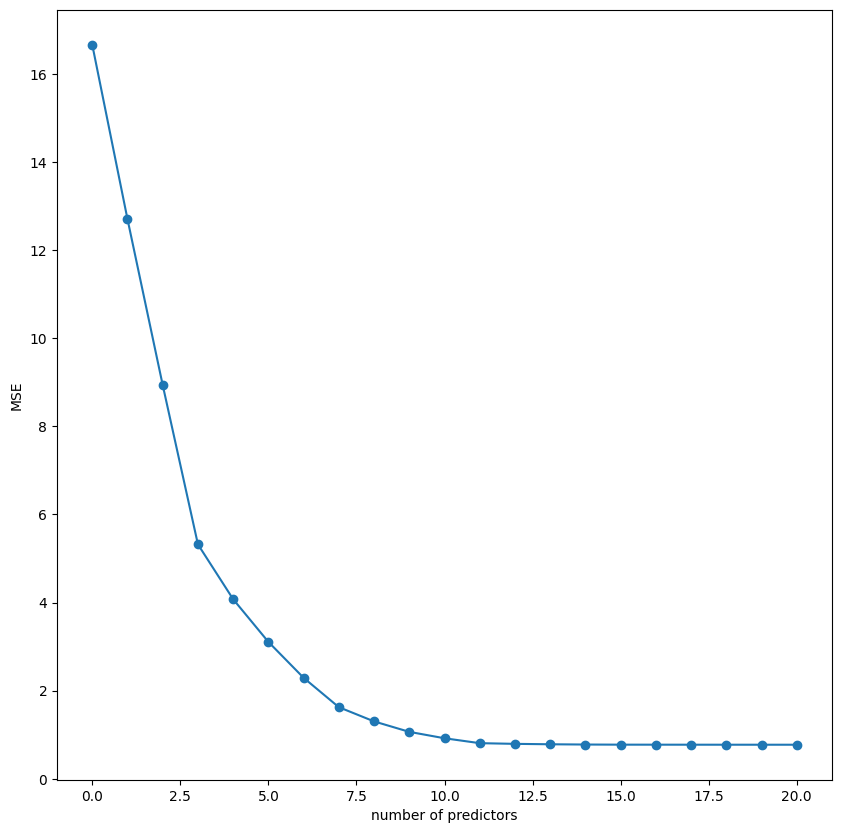

In [ ]:

msestest = []

#best mse search for each combination size
# xtrain_c = sm.add_constant(x_train) #intercept
xtest_c = sm.add_constant(x_test) #intercept
for k in range(0, p+1):
    best_mse = float('inf')
    best_coefs = np.zeros(p)
    for combo in combinations(range(p),k):
        #creates a tuple with indices for each combination
        xtrain_sub = xtrain_c[:, (0,) + combo]
        xtest_sub = xtest_c[:,(0,) +combo]
        # small time optimization
        # didn't know numpy could do column selection until my friend told me (: 

        model = sm.OLS(y_train, xtrain_sub).fit()
        y_pred = model.predict(xtest_sub)
        mse = np.mean((y_test - y_pred) ** 2)
        if mse < best_mse:
            best_mse = mse
            '''
            if k == 14:
                print(combo)
                print(model.params)
            '''
    msestest.append(best_mse)
    
 #this probably works but it takes way too much time

 
plt.figure(figsize=(10,10))
plt.plot(range(0, p+1), mses, marker='o')
plt.xlabel("number of predictors")
plt.ylabel("MSE")
plt.show()


e) [5 points] For which model size does the test set MSE take on its minimum value? Com-
ment on your results.

In [64]:
index = 0
for i in range(len(msestest)):
    if msestest[index] > msestest[i]:
        index = i

print(index, msestest[index])

index2 = 0
for i in range(len(mses)):
    if mses[index2] > mses[i]:
        index2 = i
print(index2, mses[index2])

# Model size of 14 (including intercept) seems best for the test data. I guess that makes sense, since there were 8 non-significant factors.
# There's also noise which would perhaps turn one of them fake-significant. 21 - 8 + 1 = 14.

14 1.1485774293285815
19 0.7723675563440474


(f) [5 points] How does the model at which the test set MSE is minimized compare to the
true model used to generate the data? Comment on the coefficient values.


The coefficient values are as follows:
β = (1, 0.5, 0, −0.5, −1, 1, 0.5, 2, 0, 0, 0.1, 0.2, 2, 0, 0, 0, −2, 1, 0, 0)

Out of these, 8 are 0, meaning that they bear no impact on the "true" model. And among these, two are quite low (0.1 and 0.2) meaning they bear little impact on the true model. 
This tracks because the last 8 points of the MSEs don't really have any difference, actually obscuring the model. Again, a total of "one" of these is likely being used to replicate
the epsilon noise, though, so it rounds out to around 14. (21 - 8 + 1 = 14)


g) [10 points] Create a plot displaying
qPp
j=1(βj − ˆβr
j )2 for a range of values of r, where ˆβr
j
is the jth coefficient estimate for the best model containing r coefficients. Comment on
what you observe. How does this compare to the test MSE plot from (d)?

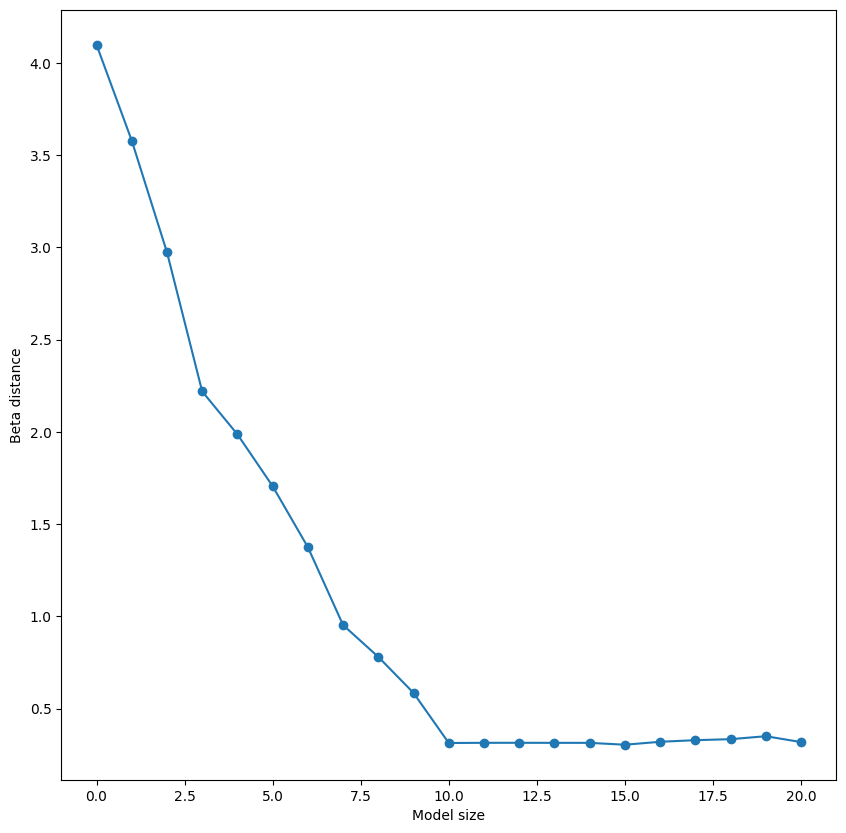

In [65]:
#in the interest of keeping each question distinct, I will re-rerun this process. 

coef_distances = []

for k in range(0, p+1):  # include 0 predictors
    best_mse = float('inf')
    best_coefs = np.zeros(p)
    for combo in combinations(range(p), k):
        xtrain_sub = x_train[:, combo]
        xtest_sub = x_test[:, combo]
        xtrain_sub = sm.add_constant(xtrain_sub)
        xtest_sub = sm.add_constant(xtest_sub)
        model = sm.OLS(y_train, xtrain_sub).fit()
        y_pred = model.predict(xtest_sub)
        mse = np.mean((y_test - y_pred) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_coefs = np.zeros(p)
            for index, column in enumerate(combo):
                best_coefs[column] = model.params[index+1]  # needs +1 because the beta doesn't have an intercept
    
    # Euclidean distance between true betas and best estimated betas
    # print(best_coefs)
    dist = np.sqrt(np.sum((beta - best_coefs)**2))
    coef_distances.append(dist)

plt.figure(figsize=(10,10))
plt.plot(range(0, p+1), coef_distances, marker='o')
plt.xlabel("Model size")
plt.ylabel("Beta distance")
plt.show()

When the model is size 10, there starts to be little to no distance between the "expected coefficients" and the actual coefficients. This is likely because adding
any more than 10 (again, 8 are dud specs) doesn't really add anything -- only 12 matter, and among them, 2 are small. The coefficients being added are likely 0.2, 0.1, and close to 0.
While it's much more intense and steep than the MSE graph, they both plateau at 10 and 11. Basically the same. 

Problem 2: [50 points - 10 points each]
Download the soccer data provided on Coursera: there are two files that you need mls train.csv
and mls test.csv. These data sets contain publicly available data of soccer players in Major
League Soccer. Our goal in this case study is to do subset selection and penalized regression to
predict a player’s salary.

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# train = np.loadtxt("_a71f23aefc674e81a52f2718adbab78a_mls_train.csv", delimiter=",", skiprows=1)
# test  = np.loadtxt("_a71f23aefc674e81a52f2718adbab78a_mls_test.csv", delimiter=","skiprows=1)
#named columns so im using pandas
# nevermind
'''
train = pd.read_csv("_a71f23aefc674e81a52f2718adbab78a_mls_train.csv", delimiter=",")
test  = pd.read_csv("_a71f23aefc674e81a52f2718adbab78a_mls_test.csv", delimiter=",")

x_train = train.drop(columns="salary")
y_train = train["salary"]

x_test = test.drop(columns="salary")
y_test = test["salary"]
'''


#don't need an intercept for scikit


train = np.loadtxt("_a71f23aefc674e81a52f2718adbab78a_mls_train.csv", delimiter=",", skiprows=1)
test  = np.loadtxt("_a71f23aefc674e81a52f2718adbab78a_mls_test.csv", delimiter=",",skiprows=1)
x_train = train[:,1:]
y_train = train[:,0]
x_test = test[:,1:]
y_test = test[:,0]



(a) Fit a best subset selection algorithm to the data set and report the best model of each
model size (up to 8 variables, excluding the intercept) and their prediction errors. Make
sure that you simplify your output to only present the essential information

In [67]:

# mses_scikit = []
# coefs_scikit = []
'''
for k in range(9): # k is predictors
    best_mse = float('inf')
    best_coefs = np.zeros(18)
    for combo in combinations(range(18),k): 
        if len(combo) == 0:
            xtrain_sub = np.ones((len(y_train),1))  # intercept only
            xtest_sub = np.ones((len(y_test),1))
        else:
            combo_list = list(combo)  
            xtrain_sub = x_train.iloc[:, combo_list]
            xtest_sub = x_test.iloc[:, combo_list]
        linreg = LinearRegression()
        model = linreg.fit(xtrain_sub,y_train)
        y_pred = linreg.predict(xtest_sub)
        mse = np.mean((y_test - y_pred) ** 2)
        if mse < best_mse:
            best_mse = mse
            coefs = np.zeros(18)
            for index, column in enumerate(combo):
                coefs[column] = linreg.coef_[index]
            best_coefs = coefs
            #using a np array vector instead of a tuple is easier
    mses_scikit.append(best_mse)
    coefs_scikit.append(best_coefs)
    
'''
# damn i didn't look ahead and realize that this needs AIC and BIC for part b. i will cry
msestest = []
mses22 = []
coefs2 = []

aics = []
bics = []
adj_r2 = []
marlows = []

full_model = sm.OLS(y_train, sm.add_constant(x_train)).fit()
sigma2_hat = full_model.ssr / (len(y_train) - x_train.shape[1] - 1)

for k in range(0, 9):  # include 0 predictors
    best_mse = float('inf')
    best_mse2 = 0
    best_coefs = np.zeros(19)
    bestaics = 0
    bestbics = 0
    bestr2 = 0
    bestmarlows = 0
    for combo in combinations(range(18), k):
        if k == 0:  # intercept-only model
            xtrain_sub = np.ones((x_train.shape[0], 1))
            xtest_sub = np.ones((x_test.shape[0], 1))
        else:
            xtrain_sub = x_train[:, combo]
            xtest_sub = x_test[:, combo]
            xtrain_sub = sm.add_constant(xtrain_sub)
            xtest_sub = sm.add_constant(xtest_sub)
        model = sm.OLS(y_train, xtrain_sub).fit()
        y_pred = model.predict(xtest_sub)
        # mse = np.mean((y_test - y_pred) ** 2)
        mse = sm.tools.eval_measures.mse(y_test,y_pred)
        if mse < best_mse:
            best_mse = mse
            best_coefs = np.zeros(19)
            for index, column in enumerate(combo):
                best_coefs[column] = model.params[index]  
            # best_mse2 = np.mean((y_train - (model.predict(xtrain_sub))) ** 2)
            best_mse2 = sm.tools.eval_measures.mse(y_train,model.predict(xtrain_sub))

            bestaics = model.aic       
            bestbics = model.bic
            bestr2 = model.rsquared_adj

            rss_r = model.ssr
            r = xtrain_sub.shape[1] - 1 
            n = len(y_train)

            bestmarlows = rss_r / sigma2_hat - (n - 2 * r)

    aics.append(bestaics)
    bics.append(bestbics)
    adj_r2.append(bestr2)
    marlows.append(bestmarlows)

    msestest.append(best_mse)
    mses22.append(best_mse2)
    coefs2.append(best_coefs)



In [68]:
train2 = pd.read_csv("_a71f23aefc674e81a52f2718adbab78a_mls_train.csv", delimiter=",")
x_train2 = train2.drop(columns="salary")

coefs_scikit2 = pd.DataFrame(coefs2,columns=["Intercept"] + list(x_train2.columns))
# coefs_scikit2 = pd.DataFrame(coefs2,columns=list(x_train2.columns))
predictor_cols = [col for col in coefs_scikit2.columns if col != "Intercept"]

# Create a new column with the concatenated non-zero predictors
coefs_scikit2["Active_Predictors"] = coefs_scikit2[predictor_cols].apply(
    lambda row: ", ".join(row.index[row != 0]), axis=1
)

# Keep only model size and this new column
summary_df = coefs_scikit2[["Active_Predictors"]]
print(summary_df)    

# print(coefs_scikit2)
# print(pd.DataFrame(msestest))


                                   Active_Predictors
0                                                   
1                                         aerial_won
2                                   mins, aerial_won
3                       mins, total_wins, aerial_won
4                       height, cm, mins, aerial_won
5           height, cm, mins, total_wins, aerial_won
6  height, cm, mins, total_wins, won_tackle, aeri...
7  height, cm, mins, total_wins, won_tackle, aeri...
8  height, cm, mins, total_wins, assist, yellow_c...


(b) Using the models reported in part (a), which is the best model acording to: (i) AIC, (ii)
BIC, (iii) Cp-Mallows, and (iv) R2
a? For each criterion, report the MSE for both training
and testing data.

In [69]:
# print("AICs: ")
'''
aics2 = pd.DataFrame(aics)
bics2 = pd.DataFrame(bics)
marlows2 = pd.DataFrame(marlows)
adj_r22 = pd.DataFrame(adj_r2)
msetr = pd.DataFrame(mses22)
msete = pd.DataFrame(msestest)
'''
# output = aics2 + bics2 + marlows2 + adj_r22 + msetr + msete
# output = pd.concat([aics2,bics2,marlows2,adj_r22,msetr, msete], axis = 1)
# print(output)
# print(aics2)

minaic = min(aics)  
minaicindex = aics.index(minaic)
print(f"Best Model for AIC: {minaicindex}. Model AIC: {minaic}. MSE's: {msestest[minaicindex]},{mses22[minaicindex]}")

minbic = min(bics)
minbicindex = bics.index(minbic)
print(f"Best Model for BIC: {minbicindex}. Model BIC: {minbic}. MSE's: {msestest[minbicindex]},{mses22[minbicindex]}")

bestr22 = max(adj_r2)
bestadjr2 = adj_r2.index(bestr22)
print(f"Best Model for R2: {bestadjr2}. Model R2: {bestr22}. MSE's: {msestest[bestadjr2]},{mses22[bestadjr2]}")

bestmallows = 0
for i in range(len(marlows)):
    if (abs(marlows[i] - (i + 1)) < abs(marlows[bestmallows] - (bestmallows + 1))):
        bestmallows = i
print(f"Best Model for Mallow's: {bestmallows}. Model Mallow's: {marlows[bestmallows]}. MSE's: {msestest[bestmallows]},{mses22[bestmallows]}")



Best Model for AIC: 8. Model AIC: 10432.509811110536. MSE's: 616410698050.2958,296811761762.9996
Best Model for BIC: 2. Model BIC: 10446.961791277148. MSE's: 629568772715.5847,309434842063.7951
Best Model for R2: 8. Model R2: 0.34780115242151366. MSE's: 616410698050.2958,296811761762.9996
Best Model for Mallow's: 8. Model Mallow's: 63.3955367248646. MSE's: 616410698050.2958,296811761762.9996


(c) Fit a ridge regression model to predict a player’s salary. Use cross-validation to select
the best regularization parameter λ.
(d) Fit a lasso regression model on the same data set. Identify which features are shrunk to
zero.

In [70]:
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

# https://medium.com/data-science/the-power-of-ridge-regression-4281852a64d6
r_alphas = np.logspace(-5,5,100)
# ridge_model = RidgeCV(alphas=r_alphas, scoring='r2')
# #this is what the article i referenced used, but we want lowest MSE so unspecified works
# also not inputting a cv results in "use the efficient Leave-One-Out cross-validation" which
# is actually not that efficient
ridge = RidgeCV(alphas=r_alphas, cv=5)
ridge_model = ridge.fit(x_train, y_train)
print("Best lambda (Ridge):", ridge_model.alpha_)
print("Ridge coefficients:", ridge_model.coef_)

lasso = LassoCV(alphas=r_alphas, cv=5, max_iter=10000)
lasso_model = lasso.fit(x_train, y_train)
print("Best lambda (Lasso):", lasso_model.alpha_)
print("Lasso coefficients:", lasso_model.coef_)

# Because indices 0, 2, 5, 9, and 10 are all 0
# the "height(cm)", "game_started", "total_wins", "yellow_card", and "won_tackle"
# parameters were disabled at the optimal lambda (62802.914)


Best lambda (Ridge): 6135.907273413163
Ridge coefficients: [  1007.53749961   7442.62759721   -284.60352819    201.37403393
  -6066.52192183  -1663.58284408  10477.54812439   2927.1827991
   3535.10222917   2718.7858468    -454.77958862 -12828.02431547
  -9803.23716792  20583.50080877    708.83761113  -2958.93304779
  -2398.68242102  11921.49250328]
Best lambda (Lasso): 79248.28983539186
Lasso coefficients: [     0.           9446.09720199     -0.             62.84099065
  -8834.56946862     -0.           7821.298474     2906.33639579
   3679.59497748      0.             -0.         -13993.30591735
 -10419.79130867  30156.58517286    834.20599291  -6342.94325086
  -1244.09734473  19277.56790035]


(e) Compare the performance of the models in (b) vs. ridge vs. lasso using the MSE. Which
model would you recommend for predicting MLS player salaries and why?

In [71]:
from sklearn import metrics

y_predr = ridge_model.predict(x_test)
print(f"Ridge MSE: {metrics.mean_squared_error(y_test, y_predr)}")

y_predl= lasso_model.predict(x_test)
print(f"Lasso MSE: {metrics.mean_squared_error(y_test, y_predl)}")

Ridge MSE: 674768169415.5375
Lasso MSE: 653864301904.2767


Personally, I'd use Lasso because it vastly simplifies the model. Like the models in B, it removes certain factors which are low or zero impact, so the model
is simpler and is more likely to include only impactful factors, but it takes a lot less time to run. The MSE is pretty high, but I guess it has to be versus
the literal "minimum MSE" optimized results.